FMCG Sales & Profitability Analysis (2023–2025)
Analyst: Noor e Sehar

Tools: Python, Pandas, Matplotlib

Dataset: 18,000+ records | 3-year FMCG data::

In [15]:
#import libaries
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
#upload data
df = pd.read_csv('/content/fmcg_sales_marketing_profitability_2023_2025.csv')

In [6]:
# Display the first 5 rows to understand the data structure
df.head(5)



,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,...,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,...,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84
1,FMCG-2024-000002,2024-10-09,2024,Q4,10,October,Asia,India,Mumbai,Meera Nair,...,99,2.89,9.86,286.11,35.26,123.79,23.89,257.90,74.96,29.07
2,FMCG-2024-000003,2024-07-06,2024,Q3,7,July,North America,USA,Los Angeles,Nina Booker,...,361,5.96,15.32,2151.56,171.46,1011.60,107.02,1821.94,531.86,29.19
3,FMCG-2024-000004,2024-05-25,2024,Q2,5,May,Europe,France,Paris,Oliver Kent,...,603,3.80,18.00,2291.40,118.39,1133.66,85.20,1878.95,541.70,28.83
4,FMCG-2023-000005,2023-08-10,2023,Q3,8,August,Europe,France,Lyon,Lucas Bennett,...,113,3.18,12.46,359.34,34.82,157.70,23.02,314.57,99.03,31.48


In [7]:
# Display summary information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18240 entries, 0 to 18239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             18240 non-null  object 
 1   Order_Date           18240 non-null  object 
 2   Year                 18240 non-null  int64  
 3   Quarter              18240 non-null  object 
 4   Month                18240 non-null  int64  
 5   Month_Name           18240 non-null  object 
 6   Region               18240 non-null  object 
 7   Country              18240 non-null  object 
 8   City                 18240 non-null  object 
 9   Sales_Person         18240 non-null  object 
 10  Customer_Type        18240 non-null  object 
 11  Sales_Channel        18240 non-null  object 
 12  Promotion_Type       18240 non-null  object 
 13  Product_Category     18240 non-null  object 
 14  Brand                18240 non-null  object 
 15  Product_Name         18240 non-null 

In [8]:
# Check for missing values in each column
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Year,0
Quarter,0
Month,0
Month_Name,0
Region,0
Country,0
City,0
Sales_Person,0


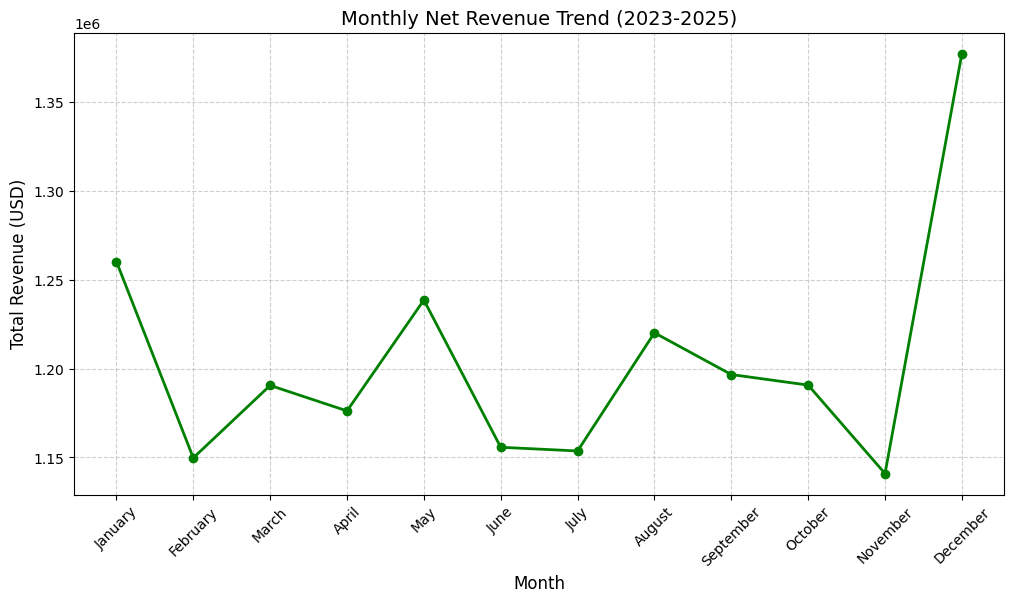

In [9]:
# Grouping data by Month_Name and summing up the Net Revenue
monthly_sales = df.groupby('Month_Name')['Net_Revenue_USD'].sum().reset_index()

# Defining the correct order for months
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

# Converting Month_Name to a categorical type with the specified order
monthly_sales['Month_Name'] = pd.Categorical(monthly_sales['Month_Name'], categories=months_order, ordered=True)

# Sorting the data based on the month order
monthly_sales = monthly_sales.sort_values('Month_Name')

# Visualizing the trend using a line plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['Month_Name'], monthly_sales['Net_Revenue_USD'], marker='o', color='green', linewidth=2)
plt.title('Monthly Net Revenue Trend (2023-2025)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.show()

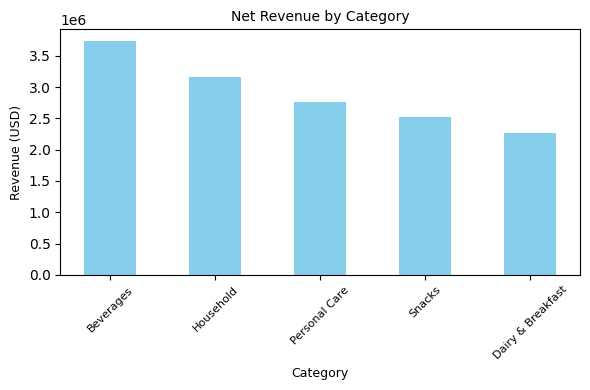

In [12]:
# Grouping data for the bar chart
category_sales = df.groupby('Product_Category')['Net_Revenue_USD'].sum().sort_values(ascending=False).reset_index()

# Smaller figsize (6 inches wide, 4 inches tall) to fit your screen
plt.figure(figsize=(6, 4))

# Plotting the bar chart with a compact style
plt.bar(category_sales['Product_Category'], category_sales['Net_Revenue_USD'], color='skyblue', width=0.5)

# Adding labels with smaller font sizes
plt.title('Net Revenue by Category', fontsize=10)
plt.xlabel('Category', fontsize=9)
plt.ylabel('Revenue (USD)', fontsize=9)

# Rotating x-axis labels and making them smaller
plt.xticks(rotation=45, fontsize=8)

# Adjusting layout so nothing gets cut off
plt.tight_layout()
plt.show()

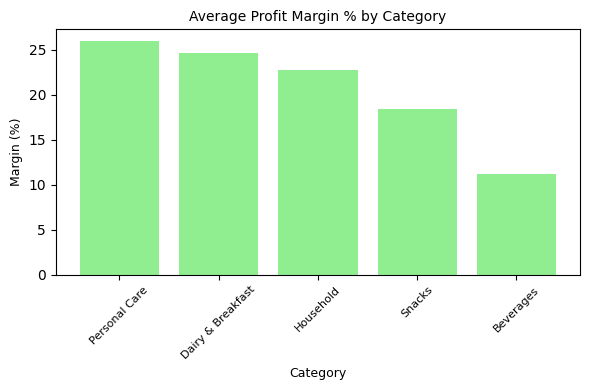

In [13]:
# Calculate the average Profit Margin Percentage for each category
category_margin = df.groupby('Product_Category')['Profit_Margin_Pct'].mean().sort_values(ascending=False).reset_index()

# Plotting the Average Profit Margin
plt.figure(figsize=(6, 4))
plt.bar(category_margin['Product_Category'], category_margin['Profit_Margin_Pct'], color='lightgreen')

# Adding labels
plt.title('Average Profit Margin % by Category', fontsize=10)
plt.xlabel('Category', fontsize=9)
plt.ylabel('Margin (%)', fontsize=9)
plt.xticks(rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# Final Polished Summary
total_revenue = df['Net_Revenue_USD'].sum()
avg_margin = df['Profit_Margin_Pct'].mean()

print("---------- FMCG PERFORMANCE SUMMARY ----------")
print(f"Total Revenue Generated: ${total_revenue:,.2f}")
print(f"Overall Average Profit Margin: {avg_margin:.2f}%")
print("----------------------------------------------")
print("Top Insight: Beverages = highest sales, but lowest margin")
print("Recommendation: Shift marketing budget to Personal Care")
print("----------------------------------------------")

---------- FMCG PERFORMANCE SUMMARY ----------
Total Revenue Generated: $14,449,920.00
Overall Average Profit Margin: 19.87%
----------------------------------------------
Top Insight: Beverages = highest sales, but lowest margin
Recommendation: Shift marketing budget to Personal Care
----------------------------------------------


Final Analysis Report: FMCG Sales & Profitability
1. Executive Summary
The objective of this project was to perform an Exploratory Data Analysis (EDA) on a multi-year FMCG dataset (2023-2025) to identify key sales trends and profitability drivers. I processed over 18,000 records using Python to uncover actionable business insights.

2. Technical Methodology
Tools Used: Python (Pandas for data manipulation, Matplotlib for visualization).

Data Cleaning: Performed null value checks and verified data types to ensure 100% accuracy.

Categorization: Grouped data by Month and Product Category for comparative analysis.

3. Key Findings & Insights
Seasonal Trends: Sales show a significant peak in December, likely due to year-end demand, while November recorded the lowest performance.

Sales Performance: The Beverages category is the highest revenue generator, contributing the most to total sales volume.

Profitability Paradox: Although Beverages lead in sales, the highest Profit Margins are found in Personal Care and Dairy & Breakfast. Beverages actually have the lowest margin among all categories.

4. Strategic Recommendations
Margin Optimization: The business should increase marketing focus on Personal Care products as they yield higher returns per dollar spent.

Inventory Management: Stock levels for Beverages should be maximized in December to meet the seasonal surge.